In [1]:
import os
# os.chdir("/content/drive/MyDrive/IowaDOT_IRI")

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
# import optuna
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
idx  = 7

Using device: cuda


In [2]:
df = pd.read_csv('processed_07_21/FINAL_DATASET_for_IRI_progression2.csv')

In [3]:
df.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
0,1,0101,1,1995,1995-10-30,0.657300,1258.24,17.900000,7.0,54.0,75,2259,5,188.0,False,False,False,388.7,0.0
1,1,0101,1,1996,1996-06-02,0.681225,1201.48,17.200001,27.0,54.0,76,3057,6,188.0,False,False,False,388.7,216.0
2,1,0101,1,1997,1997-08-24,0.694600,1475.31,17.400000,5.0,31.0,78,3879,7,188.0,False,False,False,388.7,448.0
3,1,0101,1,1998,1998-06-23,0.738225,1396.67,18.799999,0.0,23.0,76,4726,8,188.0,False,False,False,388.7,303.0
4,1,0101,1,1999,1999-09-28,0.713700,1145.22,18.500000,6.0,35.0,71,5598,9,188.0,False,False,False,388.7,462.0


In [4]:
# Define LSTM Model (Must match the original architecture)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Load the best hyperparameters from JSON
with open("models_07_21/lstm_features.json", "r") as json_file:
    lstm_features = json.load(json_file)


# Initialize model with best parameters
best_params = lstm_features['best_params']
input_dim = 14 # Should match the number of features
hidden_dim = best_params['hidden_dim']
output_dim = 1  # Single output (e.g., regression)
num_layers = best_params['num_layers']

lstm_model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)

# Load the trained weights
lstm_model.load_state_dict(torch.load("models_07_21/lstm_model.pth"))
lstm_model.eval()  # Set model to evaluation mode

print("✅ LSTM Model loaded successfully!")

import joblib

# Load the saved StandardScaler objects
lstm_scaler_features = joblib.load("models_07_21/LSTM_scaler_features.joblib")
lstm_scaler_target = joblib.load("models_07_21/LSTM_scaler_target.joblib")
lstm_scaler_age = joblib.load("models_07_21/LSTM_scaler_age.joblib")

print("✅ StandardScalers loaded successfully!")


✅ LSTM Model loaded successfully!
✅ StandardScalers loaded successfully!


/home/oguntoye/miniconda3/envs/traffic/lib/python3.13/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


#### siNGLE CHANGES

In [5]:
import pandas as pd
import numpy as np

def create_sequences(data: pd.DataFrame, seq_length: int, feature: str, rate: float):
    """
    data, dataframe for one site sorted by time
    seq_length, how many future rows to generate
    feature, either 'AADTT' for traffic growth or 'H_AC' for pavement thickness loss
    rate,
        if feature == 'AADTT', rate is a growth rate per step (for example 0.03 means 3 percent per year)
        if feature == 'H_AC', rate is the thickness loss per step in same units as H_AC and H_TOT
    """

    # make a safe working copy and clean index
    data = data.reset_index(drop=True).copy()

    # take the last known real observation as baseline
    last_row = data.iloc[-1].copy()

    # hold constant climate, freeze, humidity
    const_PRECIP = data['PRECIPITATION'].mean()
    const_TEMP = data['TEMP_MEAN_AVG'].mean()
    const_FREEZE_IND = data['FREEZE_INDEX'].mean()
    const_FREEZE_TH = data['FREEZE_THAW'].mean()
    const_HUM = data['REL_HUM_AVG_AVG'].mean()

    # structural flags stay fixed
    const_FAB = last_row['Eng_Fab']
    const_TB = last_row['Treated_Base']
    const_TS = last_row['Treated_Subbase']

    # age, we will increment by 1 each step, starting from last value
    start_age = float(last_row['AGE'])

    # traffic and thickness starting points
    start_AADTT = float(last_row['AADTT'])
    start_H_AC = float(last_row['H_AC'])
    start_H_TOT = float(last_row['H_TOT'])

    # timing anchor
    current_year = int(last_row['YEAR_VISITED'])

    # how many days since last MRI, we can choose a rule
    # simplest rule, continue increasing days since last MRI linearly, i.e., add 365 each year
    # if you want something else later we can change it
    start_days_since_mri = float(last_row['Days_since_last_MRI'])

    future_rows = []
    row_copy = last_row.copy()

    for step in range(1, seq_length + 1):
        

        # advance time like a yearly step
        row_copy['YEAR_VISITED'] = current_year + step
        row_copy['AGE'] = start_age + step

        # evolve Days_since_last_MRI
        row_copy['Days_since_last_MRI'] = start_days_since_mri + 365.0 * step

        if feature == 'AADTT':
            # compound traffic growth
            # AADTT_t = start_AADTT * (1 + rate)**step
            row_copy['AADTT'] = row_copy['AADTT'] * ((1.0 + rate * 0.01))

            # thicknesses stay fixed
            row_copy['H_AC'] = start_H_AC
            row_copy['H_TOT'] = start_H_TOT

        elif feature == 'H_AC':
            # reduce thickness each step
            new_H_AC = max(start_H_AC - rate * step, 0.0)
            new_H_TOT = max(start_H_TOT - rate * step, 0.0)
            row_copy['H_AC'] = new_H_AC
            row_copy['H_TOT'] = new_H_TOT

            # traffic stays fixed
            row_copy['AADTT'] = data['AADTT'].mean()

        else:
            raise ValueError("feature must be 'AADTT' or 'H_AC'")

        # keep climate style covariates constant at representative values
        row_copy['PRECIPITATION'] = const_PRECIP
        row_copy['TEMP_MEAN_AVG'] = const_TEMP
        row_copy['FREEZE_INDEX'] = const_FREEZE_IND
        row_copy['FREEZE_THAW'] = const_FREEZE_TH
        row_copy['REL_HUM_AVG_AVG'] = const_HUM

        # keep structure flags the same
        row_copy['Eng_Fab'] = const_FAB
        row_copy['Treated_Base'] = const_TB
        row_copy['Treated_Subbase'] = const_TS

        # VISIT_DATE for forecast rows does not exist as real inspection date
        if 'VISIT_DATE' in row_copy:
            row_copy['VISIT_DATE'] = pd.NaT

        # these ID-ish columns should not pretend to be real future inspections,
        # so blank them in the forecast copies
        if 'SHRP_ID' in row_copy:
            row_copy['SHRP_ID'] = np.nan
        if 'CONSTRUCTION_NO' in row_copy:
            row_copy['CONSTRUCTION_NO'] = np.nan

        # MRI is condition, you did not say how it evolves here
        # default, hold last observed MRI constant unless you later define a distress progression model
        row_copy['MRI'] = np.nan

        future_rows.append(row_copy)
        row_copy = future_rows[-1].copy()

    future_df = pd.DataFrame(future_rows)

    full_seq_df = pd.concat([data, future_df], ignore_index=True)

    return full_seq_df


In [6]:
pave_section = '0101' # 'A320'
new_data_len = 5
test_copy = df[df.STATE_CODE == 19]
feature = ['H_AC', 'AADTT']
IDX = 0
RATE = 2.0  # 2% traffic growth per year]
#use pavement section 18 and shrp id 6150
test_section = test_copy[test_copy.SHRP_ID == pave_section]
test_section
test_section['MRI'].iloc[-1]

last_index = len(test_section) - 1 

def develop_date(IDX, rate):
    selected_feature = feature[IDX]

    nex_data = create_sequences(test_section, seq_length=new_data_len, feature=selected_feature, rate=rate)
    test = nex_data.copy()

    srt_feaures = ['FREEZE_INDEX', 'H_AC', 'MRI', 'AGE']
    log_features = ['AADTT', 'H_TOT',  'Days_since_last_MRI']
    boolean_features = ['Eng_Fab', 'Treated_Base', 'Treated_Subbase']

    #apply the transformations

    test[srt_feaures] = np.sqrt(test[srt_feaures])
    test[log_features] = np.log1p(test[log_features])
    test[boolean_features] = test[boolean_features].astype(int)
    test['REL_HUM_AVG_AVG'] = np.log1p(lstm_features['humididty_max'] - test['REL_HUM_AVG_AVG'])

    feature_cols = lstm_features['LSTM_features']
    test[feature_cols] = lstm_scaler_features.transform(test[feature_cols])
    test['MRI'] = lstm_scaler_target.transform(test[['MRI']])
    test['AGE'] = lstm_scaler_age.transform(test[['AGE']])
    #goal is to predict MRI for the last 10 rows and revet them backl to the MRI scale

    for index in range(last_index, len(test)):
        if index == len(test) - 1:
            break
        seq_input = test.iloc[index, 5:]
        seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)
        # print(seq_input.shape, seq_input)

        with torch.no_grad():
            pred_mri = lstm_model(seq_input.unsqueeze(0)).cpu().numpy().flatten()[0]

        test.at[index + 1, 'MRI'] = pred_mri

    #dropp nan in MRI
    # test = test.dropna(subset=['MRI'])
    test['MRI'] = lstm_scaler_target.inverse_transform(test[['MRI']])
    test['MRI'] *= test['MRI']

    #inverse AGE
    test['AGE'] = lstm_scaler_age.inverse_transform(test[['AGE']])
    #square first and round to int
    test['AGE'] = (test['AGE'] ** 2).round().astype(int)

    test[feature_cols] = lstm_scaler_features.inverse_transform(test[feature_cols])


    #di anitilog for AADT and squar fro H)AC
    test['AADTT'] = np.expm1(test['AADTT'])
    test['H_TOT'] = np.expm1(test['H_TOT'])
    test['H_AC'] = test['H_AC'] ** 2

    return test

rates = [0, 4, 8, 10, 12, 15, 18, 20, 25, 30]
IDX = 1

data_1 = develop_date(IDX, rate=rates[0])
data_2 = develop_date(IDX, rate=rates[1])
data_3 = develop_date(IDX, rate=rates[2])
data_4 = develop_date(IDX, rate=rates[3])
data_5 = develop_date(IDX, rate=rates[4])
data_6 = develop_date(IDX, rate=rates[5])
data_7 = develop_date(IDX, rate=rates[6])
data_8 = develop_date(IDX, rate=rates[7])
data_9 = develop_date(IDX, rate=rates[8])
data_10 = develop_date(IDX, rate=rates[9])


/tmp/ipykernel_117520/4151563646.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)
/tmp/ipykernel_117520/4151563646.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)
/tmp/ipykernel_117520/4151563646.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_input = torc

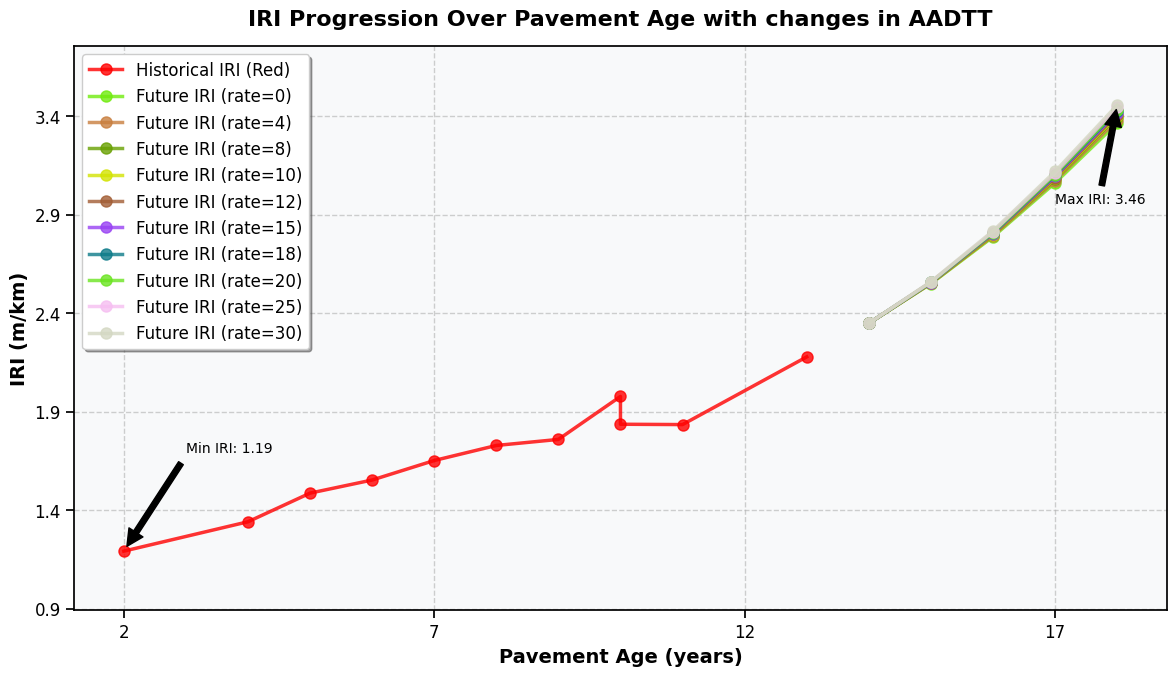

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random


# Set style and context for better aesthetics
# plt.style.use('seaborn')
sns.set_context("notebook", font_scale=1.2)

# Create figure with adjusted size
plt.figure(figsize=(12, 7), dpi=100)

# Define the split point for historical vs. future data
last_index = len(data_1) - new_data_len  # Same for all data groups

# Plot historical MRI (from data_1, as all share the same historical data)
plt.plot(data_1['AGE'][:last_index], data_1['MRI'][:last_index], 
         marker='o', 
         linestyle='-', 
         linewidth=2.5, 
         markersize=8, 
         color='red', 
         label='Historical IRI (Red)', 
         alpha=0.8)

# Define colors for future predictions (distinct and theme-compatible)
def random_color_hex():
    """
    returns a random hex color string like '#a1b2c3'
    but skips red '#ff0000' and blue '#0000ff'
    also skips pure red or pure blue in uppercase just in case formatting differs
    """
    banned = {'#ff0000', '#0000ff', '#FF0000', '#0000FF'}

    while True:
        r = random.randint(0, 255)
        g = random.randint(0, 255)
        b = random.randint(0, 255)

        hex_color = '#{:02x}{:02x}{:02x}'.format(r, g, b)

        if hex_color not in banned:
            return hex_color

# build colors list, one color per item in total

# rates = [2.0, 3.0, 4.0, 5.0]
data_groups = [data_1, data_2, data_3, data_4, data_5, data_6, data_7, data_8, data_9, data_10]
colors = [random_color_hex() for _ in range(len(data_groups))]

# Plot future (predicted) MRI for each data group
for i, (data, rate, color) in enumerate(zip(data_groups, rates, colors)):
    plt.plot(data['AGE'][last_index:], data['MRI'][last_index:], 
             marker='o', 
             linestyle='-', 
             linewidth=2.5, 
             markersize=8, 
             color=color, 
             label=f'Future IRI (rate={rate})', 
             alpha=0.8)

# Customize axes
plt.xlabel('Pavement Age (years)', fontsize=14, weight='bold')
plt.xticks(np.arange(min(data_1['AGE']), max(data_1['AGE']) + 1, step=5), fontsize=12)
plt.ylabel('IRI (m/km)', fontsize=14, weight='bold')

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# Set y-axis limits and ticks (patched block)
hist_vals = data_1['MRI'][:last_index].values
fut_vals = np.concatenate([d['MRI'][last_index:].values for d in data_groups])

hist_min = hist_vals.min()
fut_max = fut_vals.max()

ymin = max(0, hist_min - 0.3)
ymax = fut_max + 0.3

plt.ylim(ymin, ymax)
plt.yticks(np.arange(round(ymin, 1), ymax + 0.001, 0.5), fontsize=12)
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

plt.title(f'IRI Progression Over Pavement Age with changes in {feature[IDX]}', fontsize=16, weight='bold', pad=15)

# Customize grid
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend with shadow and rounded corners
plt.legend(loc='best', frameon=True, shadow=True, fancybox=True, fontsize=12)

# Add subtle background color
ax = plt.gca()
ax.set_facecolor('#f8f9fa')

# Add annotations for key points (min and max MRI across all data)
all_mri = np.concatenate([data['MRI'].values for data in data_groups])
all_age = np.concatenate([data['AGE'].values for data in data_groups])
min_mri_idx = np.argmin(all_mri)
max_mri_idx = np.argmax(all_mri)
plt.annotate(f'Min IRI: {all_mri[min_mri_idx]:.2f}', 
             xy=(all_age[min_mri_idx], all_mri[min_mri_idx]), 
             xytext=(all_age[min_mri_idx] + 1, all_mri[min_mri_idx] + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)
plt.annotate(f'Max IRI: {all_mri[max_mri_idx]:.2f}', 
             xy=(all_age[max_mri_idx], all_mri[max_mri_idx]), 
             xytext=(all_age[max_mri_idx] - 1, all_mri[max_mri_idx] - 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show plot
plt.show()


#### multi changes

In [8]:
import pandas as pd
import numpy as np

def create_sequences(
    data: pd.DataFrame,
    seq_length: int,
    feature_rates: dict
):
    """
    data, dataframe for one site sorted by time

    seq_length, how many future rows to generate

    feature_rates, dict that tells which features evolve and at what rate
        keys we recognize:
            'AADTT' , interpreted as percent growth per step
                      (for example 4.0 means 4 percent per year compounded)
            'H_AC'  , interpreted as thickness loss per step in the same units
                      as H_AC and H_TOT, applied linearly each step

        you can give one, or both, or neither
        {'AADTT': 4.0}                       traffic grows, thickness constant
        {'H_AC': 0.1}                        thickness decays, traffic fixed
        {'AADTT': 4.0, 'H_AC': 0.1}          both change
    """

    # safe copy
    data = data.reset_index(drop=True).copy()

    # last known real observation baseline
    last_row = data.iloc[-1].copy()

    # climate style covariates, compute mean and std from historical data
    climate_cols = [
        'PRECIPITATION',
        'TEMP_MEAN_AVG',
        'FREEZE_INDEX',
        'FREEZE_THAW',
        'REL_HUM_AVG_AVG'
    ]

    climate_stats = {}
    for col in climate_cols:
        col_mean = data[col].mean()
        col_std = data[col].std(ddof=0)  # population style std, avoids small sample inflation
        # handle cases where std is nan (all same value) or zero
        if np.isnan(col_std) or col_std == 0:
            col_std = 0.0
        climate_stats[col] = (col_mean, col_std)

    # structural flags stay fixed
    const_FAB = last_row['Eng_Fab']
    const_TB = last_row['Treated_Base']
    const_TS = last_row['Treated_Subbase']

    # deterministic baselines
    start_age = float(last_row['AGE'])
    start_AADTT = float(last_row['AADTT'])
    start_H_AC = float(last_row['H_AC'])
    start_H_TOT = float(last_row['H_TOT'])
    current_year = int(last_row['YEAR_VISITED'])
    start_days_since_mri = float(last_row['Days_since_last_MRI'])

    # state that will evolve
    curr_AADTT = start_AADTT
    curr_H_AC = start_H_AC
    curr_H_TOT = start_H_TOT

    # pull the scenario rates
    rate_AADTT_pct = feature_rates.get('AADTT', None)   # percent growth per step
    rate_HAC_loss  = feature_rates.get('H_AC', None)    # absolute thickness drop per step

    future_rows = []
    row_copy = last_row.copy()

    for step in range(1, seq_length + 1):

        # timelike features
        year_val = current_year + step
        age_val = start_age + step
        days_since_val = 365.25

        # evolve AADTT
        if rate_AADTT_pct is not None:
            # multiplicative growth
            curr_AADTT = curr_AADTT * (1.0 + rate_AADTT_pct * 0.01)
        else:
            # hold constant at last observed, not global mean
            curr_AADTT = start_AADTT

        # evolve thickness
        if rate_HAC_loss is not None:
            curr_H_AC = max(start_H_AC - rate_HAC_loss * step, 0.0)
            curr_H_TOT = max(start_H_TOT - rate_HAC_loss * step, 0.0)
        else:
            curr_H_AC = start_H_AC
            curr_H_TOT = start_H_TOT

        # now build the row
        row_copy['YEAR_VISITED'] = year_val
        row_copy['AGE'] = age_val
        row_copy['Days_since_last_MRI'] = days_since_val

        row_copy['AADTT'] = curr_AADTT
        row_copy['H_AC'] = curr_H_AC
        row_copy['H_TOT'] = curr_H_TOT

        # stochastic climate covariates
        for col in climate_cols:
            mu, sigma = climate_stats[col]
            if sigma == 0.0:
                sampled_val = mu
            else:
                sampled_val = np.random.normal(mu, sigma)
            row_copy[col] = sampled_val

        # structural flags do not change
        row_copy['Eng_Fab'] = const_FAB
        row_copy['Treated_Base'] = const_TB
        row_copy['Treated_Subbase'] = const_TS

        # VISIT_DATE does not exist for synthetic future
        if 'VISIT_DATE' in row_copy:
            row_copy['VISIT_DATE'] = pd.NaT

        # wipe ID-ish columns
        if 'SHRP_ID' in row_copy:
            row_copy['SHRP_ID'] = np.nan
        if 'CONSTRUCTION_NO' in row_copy:
            row_copy['CONSTRUCTION_NO'] = np.nan

        # MRI, not predicted yet at this stage
        row_copy['MRI'] = np.nan

        future_rows.append(row_copy)
        row_copy = future_rows[-1].copy()

    future_df = pd.DataFrame(future_rows)

    full_seq_df = pd.concat([data, future_df], ignore_index=True)

    return full_seq_df


In [10]:
def develop_date(feature_rates):

    nex_data = create_sequences(
        data=test_section,
        seq_length=new_data_len,
        feature_rates=feature_rates
    )
    test = nex_data.copy()

    srt_feaures = ['FREEZE_INDEX', 'H_AC', 'MRI', 'AGE']
    log_features = ['AADTT', 'H_TOT',  'Days_since_last_MRI']
    boolean_features = ['Eng_Fab', 'Treated_Base', 'Treated_Subbase']

    # apply the transformations
    test[srt_feaures] = np.sqrt(test[srt_feaures])
    test[log_features] = np.log1p(test[log_features])
    test[boolean_features] = test[boolean_features].astype(int)
    test['REL_HUM_AVG_AVG'] = np.log1p(lstm_features['humididty_max'] - test['REL_HUM_AVG_AVG'])

    feature_cols = lstm_features['LSTM_features']
    test[feature_cols] = lstm_scaler_features.transform(test[feature_cols])
    test['MRI'] = lstm_scaler_target.transform(test[['MRI']])
    test['AGE'] = lstm_scaler_age.transform(test[['AGE']])

    # goal is to predict MRI for the last new_data_len rows and write it forward
    for index in range(last_index, len(test)):
        if index == len(test) - 1:
            break

        seq_input = test.iloc[index, 5:]
        seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_mri = lstm_model(seq_input.unsqueeze(0)).cpu().numpy().flatten()[0]

        test.at[index + 1, 'MRI'] = pred_mri

    # inverse MRI
    test['MRI'] = lstm_scaler_target.inverse_transform(test[['MRI']])
    test['MRI'] *= test['MRI']

    # inverse AGE
    test['AGE'] = lstm_scaler_age.inverse_transform(test[['AGE']])
    test['AGE'] = (test['AGE'] ** 2).round().astype(int)

    # inverse feature scaling
    test[feature_cols] = lstm_scaler_features.inverse_transform(test[feature_cols])

    # undo log and sqrt transforms
    test['AADTT'] = np.expm1(test['AADTT'])
    test['H_TOT'] = np.expm1(test['H_TOT'])
    test['H_AC'] = test['H_AC'] ** 2
    test['Days_since_last_MRI'] = np.expm1(test['Days_since_last_MRI'])

    return test


In [24]:
pave_section = '0159' # 'A320'
new_data_len = 30
test_copy = df[df.STATE_CODE == 19]
feature = ['H_AC', 'AADTT']
IDX = 0
RATE = 2.0  # 2% traffic growth per year]
#use pavement section 18 and shrp id 6150
test_section = test_copy[test_copy.SHRP_ID == pave_section]
test_section
test_section['MRI'].iloc[-1]

last_index = len(test_section) - 1 

def build_scenarios_linear(
    traffic_init,
    traffic_step,
    h_ac_init,
    h_ac_step,
    n_scenarios=10
):


    traffic_rates = []
    thickness_losses = []

    for i in range(n_scenarios):
        traffic_rates.append(traffic_init + i * traffic_step)
        thickness_losses.append(h_ac_init + i * h_ac_step)

    return traffic_rates, thickness_losses

traffic_rates, thickness_losses = build_scenarios_linear(
    traffic_init = 1,    # scenario 1 traffic growth percent
    traffic_step = 1,    # add 3 percent each scenario
    h_ac_init    = 1,    # scenario 1 thickness loss per year
    h_ac_step    = 0.5,   # add 0.02 each scenario
    n_scenarios  = 5
)

# sanity check
print("traffic_rates =", traffic_rates)
print("thickness_losses =", thickness_losses)

# build list of dicts, one per scenario
feature_rates_list = []
for tr, tl in zip(traffic_rates, thickness_losses):
    feature_rates_list.append({
        'AADTT': tr,   # percent growth per year
        'H_AC': tl     # thickness loss per year
    })




data_1  = develop_date(feature_rates=feature_rates_list[0])
data_2  = develop_date(feature_rates=feature_rates_list[1])
data_3  = develop_date(feature_rates=feature_rates_list[2])
data_4  = develop_date(feature_rates=feature_rates_list[3])
data_5  = develop_date(feature_rates=feature_rates_list[4])
# data_6  = develop_date(feature_rates=feature_rates_list[5])
# data_7  = develop_date(feature_rates=feature_rates_list[6])
# data_8  = develop_date(feature_rates=feature_rates_list[7])
# data_9  = develop_date(feature_rates=feature_rates_list[8])
# data_10 = develop_date(feature_rates=feature_rates_list[9])


traffic_rates = [1, 2, 3, 4, 5]
thickness_losses = [1.0, 1.5, 2.0, 2.5, 3.0]


/tmp/ipykernel_117520/3332198601.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)
/tmp/ipykernel_117520/3332198601.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_input = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0).to(device)
/tmp/ipykernel_117520/3332198601.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_input = torc

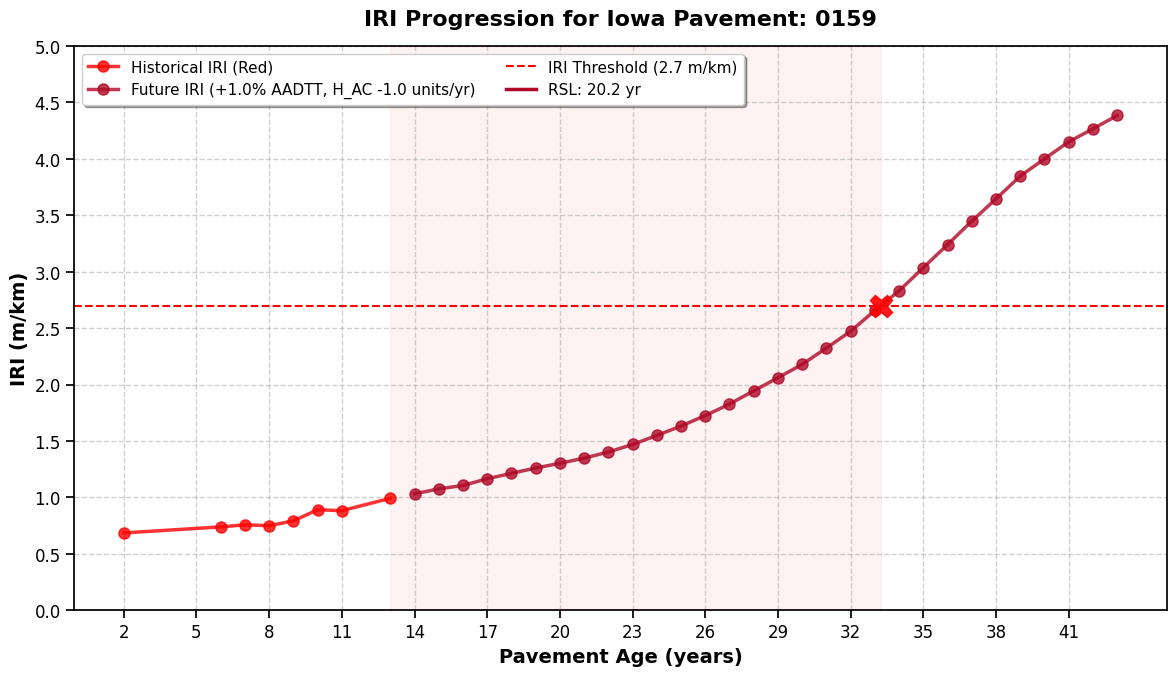

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# -------------------------------
# Configuration
# -------------------------------
step = 3
sns.set_context("notebook", font_scale=1.2)
plt.figure(figsize=(12, 7), dpi=100)

# Split point: historical vs future
last_index = len(data_1) - new_data_len

# -------------------------------
# Plot Historical IRI
# -------------------------------
plt.plot(
    data_1['AGE'][:last_index],
    data_1['MRI'][:last_index],
    marker='o', linestyle='-', linewidth=2.5, markersize=8,
    color='red', label='Historical IRI (Red)', alpha=0.8
)

# -------------------------------
# Color generator (skip pure red/blue)
# -------------------------------
def random_color_hex():
    banned = {'#ff0000', '#0000ff', '#FF0000', '#0000FF'}
    while True:
        r, g, b = random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)
        hex_color = '#{:02x}{:02x}{:02x}'.format(r, g, b)
        if hex_color not in banned:
            return hex_color

# Data groups (you can expand this list later)
data_groups = [data_1]  # or [data_1, data_2, ...]
rate = 0
colors = [random_color_hex() for _ in range(len(data_groups))]

# -------------------------------
# Plot Future IRI + RSL + FILL (NO DASHED LINE)
# -------------------------------
current_age = data_1['AGE'].iloc[last_index - 1]  # Last historical age
rsl_texts = []
fill_patches = []  # To avoid duplicate legend entries

for data, scenario_rates, color in zip(data_groups, feature_rates_list[rate:], colors):
    growth = scenario_rates['AADTT']
    loss = scenario_rates['H_AC']

    # --- Plot future curve ---
    plt.plot(
        data['AGE'][last_index:],
        data['MRI'][last_index:],
        marker='o', linestyle='-', linewidth=2.5, markersize=8,
        color=color,
        label=f'Future IRI ({growth:+.1f}% AADTT, H_AC -{loss:.1f} units/yr)',
        alpha=0.8
    )

    # --- RSL Calculation & Fill ---
    age_fut = data['AGE'][last_index:].values
    iri_fut = data['MRI'][last_index:].values

    # Find crossing
    cross_idx = np.where(iri_fut >= 2.7)[0]
    if len(cross_idx) == 0:
        rsl_text = "RSL: ∞ yr"
    else:
        i = cross_idx[0]
        if i == 0:
            age_at_27 = age_fut[0]
        else:
            x0, x1 = age_fut[i-1], age_fut[i]
            y0, y1 = iri_fut[i-1], iri_fut[i]
            age_at_27 = x0 + (x1 - x0) * (2.7 - y0) / (y1 - y0)
        rsl = age_at_27 - current_age
        rsl_text = f"RSL: {rsl:.1f} yr"

        # --- FILL: from present → crossing, full height ---
        fill = plt.fill_between(
            [current_age, age_at_27],
            0, 5,                    # <-- touches top & bottom
            color='red', alpha=0.05,
            # label='RSL zone' if not fill_patches else ""  # label only once
        )
        fill_patches.append(fill)

        # --- X marker at crossing ---
        plt.plot(age_at_27, 2.7, 'X', markersize=16, color='red', alpha=0.9)

    rsl_texts.append(rsl_text)

# -------------------------------
# Y-axis limits (fixed from your patch)
# -------------------------------
hist_vals = data_1['MRI'][:last_index].values
fut_vals = np.concatenate([d['MRI'][last_index:].values for d in data_groups])

hist_min = hist_vals.min()
fut_max = fut_vals.max()

ymin = max(0, hist_min - 0.3)
ymax = fut_max + 0.3

plt.ylim(ymin, ymax)
plt.yticks(np.arange(0, 5.5, 0.5), fontsize=12)

# -------------------------------
# Labels & Threshold Line
# -------------------------------
plt.xlabel('Pavement Age (years)', fontsize=14, weight='bold')
plt.xticks(np.arange(min(data_1['AGE']), max(data_1['AGE']) + 1, step=step), fontsize=12)
plt.ylabel('IRI (m/km)', fontsize=14, weight='bold')

plt.title(f'IRI Progression for Iowa Pavement: {pave_section}',
          fontsize=16, weight='bold', pad=15)

plt.axhline(y=2.7, color='red', linestyle='--', linewidth=1.5,
            label='IRI Threshold (2.7 m/km)')

# -------------------------------
# Legend: Combine original + RSL
# -------------------------------
handles, labels = plt.gca().get_legend_handles_labels()

# Add RSL as secondary legend entries (same color)
for color, rsl_text in zip(colors, rsl_texts):
    handles.append(plt.Line2D([], [], color=color, linewidth=2.5))
    labels.append(rsl_text)



plt.legend(handles, labels,
           loc='upper left', frameon=True, shadow=True, fancybox=True,
           fontsize=11, ncol=2)  # 2 columns for clarity

# -------------------------------
# Final Touches
# -------------------------------
plt.grid(True, linestyle='--', alpha=0.6)
# ax = plt.gca()
# ax.set_facecolor('#f8f9fa')
fig = plt.gcf()
fig.patch.set_facecolor('white')          # Figure background
ax = plt.gca()
ax.set_facecolor('white')                 # Axes (plot area) background

plt.tight_layout()
plt.show()

In [89]:
data_2.tail()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
33,19,NaN,NaN,2030,NaN,3.235531,497.853509,11.988522,15.570197,95.118096,2.719799,4934.308892,39,62.34,0,1,0,1154.54,365.25
34,19,NaN,NaN,2031,NaN,3.427374,829.825558,11.810743,18.719828,75.119601,3.072464,4959.473867,40,60.83,0,1,0,1153.03,365.25
35,19,NaN,NaN,2032,NaN,3.600432,1568.401332,10.429301,18.733628,77.128294,2.902475,4984.767184,41,59.32,0,1,0,1151.52,365.25
36,19,NaN,NaN,2033,NaN,3.727798,569.219623,11.322062,18.457509,100.754857,3.020621,5010.189497,42,57.81,0,1,0,1150.01,365.25
37,19,NaN,NaN,2034,NaN,3.859379,1544.699711,11.002936,21.677152,101.193029,2.320455,5035.741463,43,56.30,0,1,0,1148.50,365.25


#### SINGLE TABLE

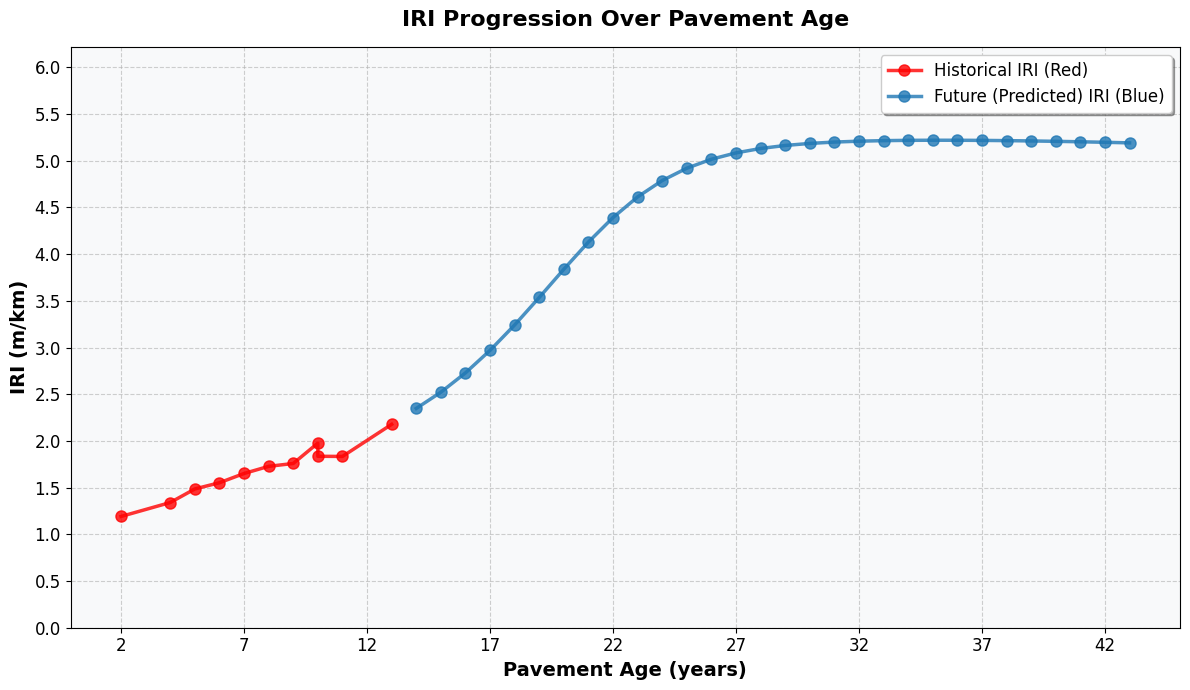

In [243]:
#plot the results use age as X axis, dope na first and inver age first

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
step = 5

# Set style and context for better aesthetics
# plt.style.use('seaborn')
# sns.set_context("notebook", font_scale=1.2)

# Create figure with adjusted size
plt.figure(figsize=(12, 7), dpi=100)

# Define the split point
last_index = len(test) - new_data_len  # Assuming last_index is where the last 10 rows start

# Plot historical MRI up to last_index with red color
plt.plot(test['AGE'][:last_index], test['MRI'][:last_index], 
         marker='o', 
         linestyle='-', 
         linewidth=2.5, 
         markersize=8, 
         color='red', 
         label='Historical IRI (Red)', 
         alpha=0.8)

# Plot historical MRI from last_index to end with blue color
plt.plot(test['AGE'][last_index:], test['MRI'][last_index:], 
         marker='o', 
         linestyle='-', 
         linewidth=2.5, 
         markersize=8, 
         color='#1f77b4', 
         label='Future (Predicted) IRI (Blue)', 
         alpha=0.8)

# Customize axes
plt.xlabel('Pavement Age (years)', fontsize=14, weight='bold')
# plt.xticks(rotation=45)

#use range of 1 on x axis
plt.xticks(np.arange(min(test['AGE']), max(test['AGE']) + 1, step=step), fontsize=12)
plt.ylabel('IRI (m/km)', fontsize=14, weight='bold')
plt.title('IRI Progression Over Pavement Age', fontsize=16, weight='bold', pad=15)

#fitx the y axis to be from 0 to 5 with space of 0.5
plt.ylim(0, max(test['MRI']) + 1)
plt.yticks(np.arange(0, max(test['MRI']) + 1, step=0.5))
# Customize grid
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend with shadow and rounded corners
plt.legend(loc='best', frameon=True, shadow=True, fancybox=True, fontsize=12)

# Add subtle background color
ax = plt.gca()
ax.set_facecolor('#f8f9fa')

# Add annotations for key points (e.g., min and max MRI)
min_mri_idx = test['MRI'].idxmin()
max_mri_idx = test['MRI'].idxmax()


# Set tick parameters for better readability
# plt.xticks(np.arange(min(test['AGE']), max(test['AGE']) + 1, step=1), fontsize=12)
plt.yticks(fontsize=12)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
#return AADT and H_AC to original scale
#user LSTm_inverse feature

test

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
0,19,A320,1.0,1990,1990-06-17,1.240300,909.430000,9.400000,20.880613,120.000000,3.044522,1934.000000,39,149.9,0,1,0,335.3,0.000000
1,19,A320,2.0,1991,1991-06-20,1.570900,1031.940000,8.700000,26.683328,98.000000,2.772589,2003.000000,40,155.0,0,1,0,340.4,5.910797
2,19,A320,2.0,1992,1992-05-12,1.654900,967.630000,8.400000,20.371549,121.000000,2.639057,2062.000000,41,155.0,0,1,0,340.4,5.793014
3,19,A320,2.0,1993,1993-10-17,1.509300,1484.830000,7.000000,27.694765,100.000000,2.197225,2100.000000,42,155.0,0,1,0,340.4,6.261492
4,19,A320,2.0,1994,1994-09-17,1.496600,898.760000,8.300000,28.774989,81.000000,2.772589,2213.000000,43,155.0,0,1,0,340.4,5.817111
5,19,A320,2.0,1997,1997-08-07,1.794300,759.710000,8.700000,25.119713,112.000000,2.944439,2547.000000,46,155.0,0,1,0,340.4,6.962243
6,19,NaN,NaN,1998,NaN,1.885949,1008.716667,8.416667,25.129664,105.333333,2.762117,2143.166667,47,153.0,0,1,0,338.4,7.259116
7,19,NaN,NaN,1999,NaN,1.991838,1008.716667,8.416667,25.129664,105.333333,2.762117,2143.166667,48,151.0,0,1,0,336.4,7.487734
8,19,NaN,NaN,2000,NaN,2.114920,1008.716667,8.416667,25.129664,105.333333,2.762117,2143.166667,49,149.0,0,1,0,334.4,7.673688
9,19,NaN,NaN,2001,NaN,2.256160,1008.716667,8.416667,25.129664,105.333333,2.762117,2143.166667,50,147.0,0,1,0,332.4,7.830426


#### maintenace then progresion

In [236]:
embed_df = pd.read_parquet('DATA_07_26/maintenance_embeddings.parquet')

In [237]:
embed_df.head(1)

,text,text-embedding-3-small_128,text-embedding-3-small_256,text-embedding-3-small_384,text-embedding-3-small_512,text-embedding-3-small_640,text-embedding-3-small_768,text-embedding-3-small_896,text-embedding-3-small_1024,text-embedding-3-small_1152,...,text-embedding-3-large_1920,text-embedding-3-large_2048,text-embedding-3-large_2176,text-embedding-3-large_2304,text-embedding-3-large_2432,text-embedding-3-large_2560,text-embedding-3-large_2688,text-embedding-3-large_2816,text-embedding-3-large_2944,text-embedding-3-large_3072
0,AC Shoulder Replacement,"[-0.04659799858927727, -0.12649698555469513, 0...","[-0.031830642372369766, -0.08640886843204498, ...","[-0.026324069127440453, -0.07146048545837402, ...","[-0.02265769988298416, -0.06150759756565094, 0...","[-0.02113918960094452, -0.05738538131117821, 0...","[-0.01996253803372383, -0.054191190749406815, ...","[-0.018844328820705414, -0.05115564912557602, ...","[-0.01783447340130806, -0.04841425269842148, 0...","[-0.017086762934923172, -0.04638448357582092, ...",...,"[-0.014538077637553215, 0.0046240342780947685,...","[-0.01428484357893467, 0.0045168730430305, -0....","[-0.014050411060452461, 0.004454785026609898, ...","[-0.013848558068275452, 0.0044047231785953045,...","[-0.013676420785486698, 0.00434997258707881, -...","[-0.013492313213646412, 0.004291414748877287, ...","[-0.013295467011630535, 0.0042288051918148994,...","[-0.013118491508066654, 0.004172515589743853, ...","[-0.012934292666614056, 0.004113928880542517, ...","[-0.012735559605062008, 0.0040507190860807896,..."


In [238]:
tmp_df = embed_df.iloc[:, [0, idx]]
embed_col = tmp_df.columns[1]

print(embed_col)
size = embed_col.split('_')[1]
print(size)

# print(size)
#read the parque tsing the embed_col ref
df_total = pd.read_parquet(f'DATA_07_26/dataframe_for_IRI_drop_{embed_col}.parquet')

text-embedding-3-small_896
896


In [239]:
df_total

,STATE_CODE,SHRP_ID,YEAR,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,MRI_BEFORE,...,embedding_886,embedding_887,embedding_888,embedding_889,embedding_890,embedding_891,embedding_892,embedding_893,embedding_894,embedding_895
0,1,0107,1999,9,116.9,False,True,False,320.1,0.75680,...,0.005495,0.034931,-0.005560,-0.008798,0.010117,-0.029768,-0.013451,-0.026757,0.024410,0.019311
1,1,0502,1991,16,88.9,False,False,False,505.5,1.03600,...,0.041042,0.022780,-0.013175,0.021643,-0.036208,-0.039463,0.020237,0.002480,-0.024376,0.061611
2,1,0503,1991,16,83.8,False,False,False,500.4,0.99050,...,0.016075,0.008230,0.022100,0.043740,-0.026674,-0.018821,0.036986,0.017837,-0.039412,0.058266
3,1,0504,1991,16,88.9,False,False,False,500.4,1.03070,...,0.002083,0.029201,0.025585,0.046641,-0.016755,-0.017659,0.048905,0.029691,-0.031635,0.026852
4,1,0505,1991,16,83.9,False,False,False,500.5,1.13720,...,0.003424,0.052162,-0.002501,0.032072,-0.025930,-0.016574,0.041865,0.031853,-0.010660,0.017533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1582,90,B350,1990,22,53.3,False,True,False,312.4,0.97540,...,-0.022851,0.022348,-0.037073,0.016244,-0.003157,-0.035246,0.055507,0.041677,0.013057,0.017427
1583,90,B350,1995,27,60.9,False,True,False,320.0,1.40105,...,-0.004152,0.048131,0.005671,0.002166,-0.003147,-0.010378,0.006062,-0.010952,0.020589,0.000132
1584,90,B350,1998,30,60.9,False,True,False,320.0,2.09430,...,0.005495,0.034931,-0.005560,-0.008798,0.010117,-0.029768,-0.013451,-0.026757,0.024410,0.019311
1585,90,B351,1990,22,78.7,False,True,False,337.8,1.44810,...,-0.022851,0.022348,-0.037073,0.016244,-0.003157,-0.035246,0.055507,0.041677,0.013057,0.017427


In [240]:
df_total = df_total[df_total.STATE_CODE == 19]
test_total = df_total.drop(columns = ['YEAR', 'MAINTENANCE'])

Index(['STATE_CODE', 'SHRP_ID', 'AGE', 'H_AC', 'Eng_Fab', 'Treated_Base',
       'Treated_Subbase', 'H_TOT', 'MRI_BEFORE', 'MRI_AFTER',
       'DAYS_SINCE_MAINTENANCE', 'Added_Thickness', 'AADTT', 'embedding_0'],
      dtype='object')

In [241]:
class DualBranchNN(nn.Module):
    def __init__(self, input_size_numeric, input_size_text, best_params):
        super(DualBranchNN, self).__init__()

        # Optimized text processing branch
        self.text_branch = nn.Sequential(
            nn.Linear(input_size_text, best_params["reduced_text_size"]),
            nn.ReLU(),
            nn.Dropout(best_params["dropout_text"])
        )

        # Optimized structured data branch
        self.numeric_branch = nn.Sequential(
            nn.Linear(input_size_numeric, best_params["numeric_hidden_size"]),
            nn.ReLU(),
            nn.Dropout(best_params["dropout_numeric"])
        )

        # Optimized merged final layer
        self.final_layer = nn.Sequential(
            nn.Linear(best_params["reduced_text_size"] + best_params["numeric_hidden_size"],
                      best_params["final_hidden_size"]),
            nn.ReLU(),
            nn.Linear(best_params["final_hidden_size"], 1)
        )

    def forward(self, text_embedding, numeric_features):
        text_out = self.text_branch(text_embedding)
        num_out = self.numeric_branch(numeric_features)
        combined = torch.cat((text_out, num_out), dim=1)
        output = self.final_layer(combined)
        return output


In [247]:
import json
#CHANGE HERE

with open(f"models_07_26/{embed_col}/ANN_features.json", "r") as json_file:
    ANN_features = json.load(json_file)

# Instantiate model with the correct input sizes
best_params = ANN_features['best_params']

input_size_numeric = 10
input_size_text = eval(size)
print(input_size_text)

ann_model = DualBranchNN(input_size_numeric, input_size_text, best_params).to(device)

# Load the saved weights
ann_model.load_state_dict(torch.load(f"models_07_26/{embed_col}/DualBranchNN_model.pth"))
ann_model.eval()  # Set to evaluation mode

print("✅ DualBranchNN model loaded successfully!")

896
✅ DualBranchNN model loaded successfully!


In [243]:
def transform(df_total):
    sqrt_transform = [ 'H_AC', 'AGE', 'DAYS_SINCE_MAINTENANCE' ]
    log_transform = ['H_TOT', 'MRI_BEFORE', 'MRI_AFTER', 'AADTT',  'Added_Thickness']
    booleans = ['Eng_Fab', 'Treated_Base', 'Treated_Subbase']

    # Apply square root transformation (avoid NaN for negative values)
    for feature in sqrt_transform:
        df_total[feature] = np.sqrt(df_total[feature])  # Ensure non-negative values

    # Apply log transformation (avoid NaN for negative values)
    for feature in log_transform:
        df_total[feature] = np.log1p(df_total[feature].clip(0, None))  # Ensure non-negative values
        df_total[feature] = df_total[feature].fillna(0)  # Fill NaNs with 0 (if any)

    # Apply integer conversion to booleans (ensure only 0 and 1)
    for feature in booleans:
        df_total[feature] = df_total[feature].astype(bool).astype(int)

    return df_total

In [248]:
import joblib
#CHANGE

# Load the saved StandardScaler objects
ann_scaler_features = joblib.load(f"models_07_26/{embed_col}/ANN_standardizer_features.joblib")
ann_scaler_target = joblib.load(f"models_07_26/{embed_col}/ANN_standardizer_target.joblib")


print("✅ StandardScalers loaded successfully!")

✅ StandardScalers loaded successfully!


/home/oguntoye/miniconda3/envs/traffic/lib/python3.13/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [249]:
test_total.columns[:14]

Index(['STATE_CODE', 'SHRP_ID', 'AGE', 'H_AC', 'Eng_Fab', 'Treated_Base',
       'Treated_Subbase', 'H_TOT', 'MRI_BEFORE', 'MRI_AFTER',
       'DAYS_SINCE_MAINTENANCE', 'Added_Thickness', 'AADTT', 'embedding_0'],
      dtype='object')

In [250]:
ann_scaler_features.feature_names_in_

array(['AGE', 'H_AC', 'H_TOT', 'MRI_BEFORE', 'DAYS_SINCE_MAINTENANCE',
       'Added_Thickness', 'AADTT'], dtype=object)

In [ ]:
def standardize(data):
      data[ANN_features['ann_features']] = ann_scaler_features.transform(data[ANN_features['ann_features']])
      data['MRI_AFTER'] = ann_scaler_target.transform(data[['MRI_AFTER']])

      return data

test_drop = standardize(test_drop)
# print(test_drop)
features = ANN_features['ann_features'] + ["Eng_Fab", "Treated_Base", "Treated_Subbase"]

target_col = "MRI_AFTER"
feature_cols_text = test_drop.columns[13:]
X_train_struct = test_drop[features]  # Drop MRI
X_train_text = test_drop[feature_cols_text]
y_train = test_drop[target_col]
# Convert already preprocessed data to PyTorch tensors

# print(X_train_struct)
numeric_tensor = torch.tensor(X_train_struct.values, dtype=torch.float32).to(device)
text_tensor = torch.tensor(X_train_text.values, dtype=torch.float32).to(device)

# Perform batch prediction
with torch.no_grad():
    # print('here')
    predictions = ann_model(text_tensor, numeric_tensor)

# Convert predictions to NumPy
predicted_values = predictions.cpu().numpy().flatten()



# Inverse transform the predicted and actual values
actual_values = ann_scaler_target.inverse_transform(y_train.values.reshape(-1, 1)).flatten()
predicted_values = ann_scaler_target.inverse_transform(predicted_values.reshape(-1, 1)).flatten()

#inverlog
predicted_values = np.expm1(predicted_values)
actual_values = np.expm1(actual_values)

In [231]:
data_1

#update the iniital data with maitennace data output


,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
0,19,0109,1.0,1993,1993-10-15,0.789600,1576.780000,9.500000,21.330729,90.000000,1.791759,331.0,2,188.0,0,1,0,1275.1,0.0
1,19,0109,1.0,1995,1995-02-15,0.782400,1114.200000,10.100000,21.283797,90.000000,2.639057,828.0,4,188.0,0,1,0,1275.1,488.0
2,19,0109,1.0,1996,1996-04-16,0.947100,1118.010000,9.900000,22.090722,106.000000,2.890372,1159.0,5,188.0,0,1,0,1275.1,426.0
3,19,0109,1.0,1997,1997-09-25,0.821500,988.100000,10.700000,19.078784,111.000000,2.890372,1544.0,6,188.0,0,1,0,1275.1,527.0
4,19,0109,1.0,1998,1998-10-13,0.847300,1205.610000,12.300000,15.620499,80.000000,2.484907,1893.0,7,188.0,0,1,0,1275.1,383.0
5,19,0109,1.0,1999,1999-07-19,0.855800,717.130000,11.900000,16.852300,100.000000,2.944439,2293.0,8,188.0,0,1,0,1275.1,279.0
6,19,0109,1.0,2000,2000-05-22,0.867600,735.950000,11.700000,20.928450,89.000000,3.044522,2691.0,9,188.0,0,1,0,1275.1,308.0
7,19,0109,1.0,2001,2001-05-29,0.899100,1118.090000,11.600000,17.972201,94.000000,2.772589,3097.0,10,188.0,0,1,0,1275.1,372.0
8,19,0109,2.0,2001,2001-08-06,1.169300,1118.090000,11.600000,17.972201,94.000000,2.772589,3097.0,10,188.0,0,1,0,1275.1,69.0
9,19,0109,2.0,2002,2002-11-22,1.049800,763.190000,11.600000,14.662878,121.000000,2.833213,3487.0,11,188.0,0,1,0,1275.1,473.0


In [ ]:
maintenance = ['AC Shoulder Replacement']
import pandas as pd
import numpy as np

def add_maintenance(
    data: pd.DataFrame,
    maintenance: dict
):

    # safe copy
    data = data.reset_index(drop=True).copy()

    # last known real observation baseline
    last_row = data.iloc[-1].copy()


    # structural flags stay fixed
    const_FAB = last_row['Eng_Fab']
    const_TB = last_row['Treated_Base']
    const_TS = last_row['Treated_Subbase']

    # deterministic baselines
    start_age = float(last_row['AGE'])
    start_AADTT = float(last_row['AADTT'])
    start_H_AC = float(last_row['H_AC'])
    start_H_TOT = float(last_row['H_TOT'])
    current_year = int(last_row['YEAR_VISITED'])
    DAYS_SINCE_MAINT = int(300)
# 
    curr_AADTT = start_AADTT


    for step in range(1):

        # timelike features
        year_val = current_year + step
        age_val = start_age + step

        # now build the row
        row_copy['YEAR_VISITED'] = year_val
        row_copy['AGE'] = age_val
        row_copy['Days_since_last_MRI'] = DAYS_SINCE_MAINT

        row_copy['AADTT'] = start_AADTT
        row_copy['H_AC'] = start_H_AC
        row_copy['H_TOT'] = start_H_TOT

        # structural flags do not change
        row_copy['Eng_Fab'] = const_FAB
        row_copy['Treated_Base'] = const_TB
        row_copy['Treated_Subbase'] = const_TS

        # VISIT_DATE does not exist for synthetic future
        if 'VISIT_DATE' in row_copy:
            row_copy['VISIT_DATE'] = pd.NaT

        # wipe ID-ish columns
        if 'SHRP_ID' in row_copy:
            row_copy['SHRP_ID'] = np.nan
        if 'CONSTRUCTION_NO' in row_copy:
            row_copy['CONSTRUCTION_NO'] = np.nan

        # MRI, not predicted yet at this stage
        row_copy['MRI'] = np.nan

        future_rows.append(row_copy)
        row_copy = future_rows[-1].copy()

    future_df = pd.DataFrame(future_rows)

    full_seq_df = pd.concat([data, future_df], ignore_index=True)

    return full_seq_df
